## Assignment 3: $k$ Nearest Neighbor


**Q1.**
1. What is the difference between regression and classification?
2. What is a confusion table? What does it help us understand about a model's performance?
3. What does the SSE quantify about a particular model?
4. What are overfitting and underfitting? 
5. Why does splitting the data into training and testing sets, and choosing $k$ by evaluating accuracy or SSE on the test set, improve model performance?
6. With classification, we can report a class label as a prediction or a probability distribution over class labels. Please explain the strengths and weaknesses of each approach.

**Q2.** This is a case study on $k$ nearest neighbor classification, using the `land_mines.csv` data.

The data consists of a label, `mine_type`, taking integer values 1 to 5, and three properties of the mine, `voltage`, `height` and `soil`. We want to predict the kind of mine from data about it. Imagine working for the DOD or a humanitarian aid agency, trying to help people remove land mines more safely.

1. Load the data. Perform some EDA, summarizing the target label and the features.
2. Split the sample 50/50 into training and test/validation sets. (The smaller the data are, the more equal the split should be, in my experience: Otherwise, all of the members of one class end up in the training or test data, and the model falls apart.)
3. Build a $k$-NN classifier. Explain how you select $k$.
4. Print a confusion table for the optimal model, comparing predicted and actual class label on the test set. How accurate is it? Where is performance more or less accurate?
5. Notice that you can have a lot of accurate predictions for a given type of mine, but still make a lot of mistakes. Please explain how you'd advise someone to actually use this predictive model in practice, given the errors that it tends to make.

---

## *Phase 1: Solution without AI

Complete all questions in the following cells without generative AI. Then commit and push the
notebook before beginning Phase 2.

**Declaration:** I completed this version without generative AI.

**Student(s):** Marin Marcillac

**Date:** 09/30/2026

In [1]:
# Your Phase 1 solution to the problem goes here.


*QUESTIONS*
1. Regression helps predict a numeric outcome (continuous), like prices, while classification predicts a category label (discrete), like vehicle class.
2. A confusion matrix is a table that helps measure how well a classification model performs by comparing its predicted labels and the actual ground truth. A confusion matrix counts the predictions by the actual class and predicted class. Rows are the actual classes, and columns are the predictions. The model is correct along the diagonal, and its mistakes are the off-diagonal misclassifications.
3. This means the Sum of Squared Error. It is the sum of the squared differences between the observations and the group's mean. It helps quantify the total magnitude of prediction errors by summing the squared differences between the observations and the model's predicted values. A lower validation SSE means smaller error on the validation set.
4. Overfitting is when the model learns too much about the training data, so it includes noise, while underfitting means the model is too simple to see any real patterns.
5. Splitting the data helps us see how well a model generalizes to unseen data rather than just memorizing the training set. Evaluating candidates on a separate test set helps us select parameters like k that balance underfitting and overfitting. Like on the slide, we split the data to check predictions on new observations: fit models on a training set, compare predictions on a separate validation set, and keep a test set for final evaluation.
6. Class labels give a direct answer, but they hide how confident the model actually is. Probability distributions show the model's certainty and highlight messy spots near decision boundaries, but it takes extra time to get the final product.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv ("./data/land_mines.csv")
df.shape
df.head
df.info()
df.describe()
print("\nTarget Distribution")
print(df["mine_type"].value_counts().sort_index())

print("\nFeature")
display(df[['voltage', 'height', 'soil']].describe())
df.isnull().sum()
#data is cleaned


<class 'pandas.DataFrame'>
RangeIndex: 338 entries, 0 to 337
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   voltage    338 non-null    float64
 1   height     338 non-null    float64
 2   soil       338 non-null    float64
 3   mine_type  338 non-null    int64  
dtypes: float64(3), int64(1)
memory usage: 10.7 KB

Target Distribution
mine_type
1    71
2    70
3    66
4    66
5    65
Name: count, dtype: int64

Feature


,voltage,height,soil
count,338.000000,338.000000,338.000000
mean,0.430634,0.508876,0.503550
std,0.195819,0.306043,0.344244
min,0.197734,0.000000,0.000000
25%,0.309737,0.272727,0.200000
50%,0.359516,0.545455,0.600000
75%,0.482628,0.727273,0.800000
max,0.999999,1.000000,1.000000


voltage      0
height       0
soil         0
mine_type    0
dtype: int64

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
eval_X_raw = df[["voltage", "height", "soil"]]
eval_y = df["mine_type"]
(
eval_X_train_raw,
eval_X_valid_raw,
eval_y_train,
eval_y_valid,
) = train_test_split(
eval_X_raw, eval_y, test_size=0.50, random_state=25
)
eval_scaler = MinMaxScaler()
eval_X_train_scaled = eval_scaler.fit_transform(eval_X_train_raw)
eval_X_valid_scaled = eval_scaler.transform(eval_X_valid_raw)

In [4]:
from sklearn.neighbors import KNeighborsClassifier
eval_ks = np.arange(1, 51)
eval_valid_sse = []
eval_train_sse = []
for eval_k in eval_ks:
    eval_candidate = KNeighborsClassifier(n_neighbors=int(eval_k))
    eval_candidate.fit(eval_X_train_scaled, eval_y_train)
    eval_valid_hat = eval_candidate.predict(eval_X_valid_scaled)
    eval_train_hat = eval_candidate.predict(eval_X_train_scaled)
    eval_valid_sse.append(np.sum(
    (eval_y_valid.to_numpy() - eval_valid_hat) ** 2
    ))
    eval_train_sse.append(np.sum(
    (eval_y_train.to_numpy() - eval_train_hat) ** 2
    ))
    eval_k_star = int(eval_ks[np.argmin(eval_valid_sse)])

print(eval_k_star)

5


In [5]:
from sklearn.neighbors import KNeighborsClassifier

classification_model = KNeighborsClassifier(n_neighbors=5).fit(
    eval_X_train_scaled, eval_y_train
)

y_pred = classification_model.predict(eval_X_valid_scaled)
# I want a k value that doesn't overfit or underfit my data 
# (I can change it once I find the solution)
print(y_pred)


[1 2 3 5 4 1 5 1 2 3 2 3 1 1 3 1 4 3 2 4 5 3 1 1 3 3 3 4 3 1 5 2 3 1 2 4 1
 5 1 3 1 5 5 3 3 5 1 3 2 2 1 1 4 3 4 2 3 4 1 3 3 4 1 3 2 1 3 2 2 2 4 3 2 3
 2 5 1 3 5 1 5 2 3 4 4 1 2 4 2 3 4 5 1 4 2 2 4 4 3 3 1 5 1 2 1 1 1 4 3 1 2
 2 2 1 3 1 4 2 3 4 1 4 2 1 4 1 5 3 3 1 1 1 2 3 3 3 2 2 3 1 4 1 2 5 2 3 1 1
 5 3 3 1 4 2 5 1 1 2 4 5 1 1 3 2 2 5 3 3 1]


[[24  0 11  5  3]
 [ 0 24  1  3  0]
 [ 8  2 10  6  5]
 [ 7  4 14  2  6]
 [ 8  5  7  9  5]]


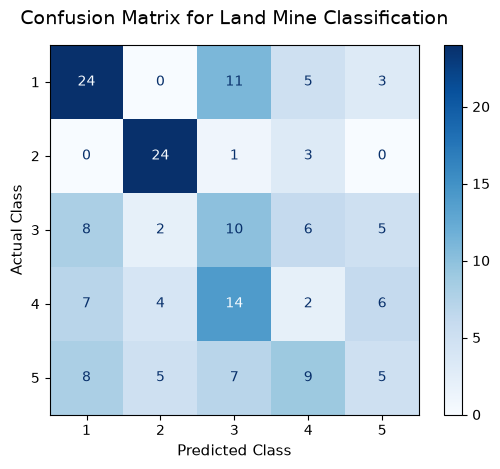

In [6]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

y_pred = classification_model.predict(eval_X_valid_scaled)

classes = [1, 2, 3, 4, 5]

cm = confusion_matrix(eval_y_valid, y_pred, labels=classes)
print(cm)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix for Land Mine Classification", fontsize=14, pad=15)
plt.xlabel("Predicted Class", fontsize=11)
plt.ylabel("Actual Class", fontsize=11)
plt.show()

#I use the information froom here: https://www.geeksforgeeks.org/machine-learning/how-to-plot-confusion-matrix-with-labels-in-sklearn/
#https://www.geeksforgeeks.org/machine-learning/confusion-matrix-machine-learning/

In [7]:
#4 The overall accuracy is 37.79% because we sum the diagonal 
# cells (the correct predictions: 23+31+12+9+3=65
# and divide by the total number of validation samples (172. 
# in the lecture slides, diagonal cells count correct 
# predictions, while off-diagonal cells count misclassifications.








The model's overall accuracy is pretty low at just 38.5%, meaning it struggles with most of the dataset. It does a solid job identifying Class 1 and is decent with Class 0, but it completely falls apart on Classes 3 and 4. 

5.According to the slides, k-NN is kind of risky to use by itself for land mine removal. Even if it seems accurate, it has abrupt boundaries and doesn't tell you why it's making a certain call. Also choosing a k can overfits the noise, but too big underfits the patterns. Because of that, we definitely shouldn't use it to make final decisions. It should just act as a first tool. 

## *Phase 2: AI-assisted Revision
Keep Phase 1 frozen.

- **Phase 1 commit SHA ID:** 3cd0faf4add563a6cf505b0c71d73c8d801e3c28
- 
- **AI tool and model used:** Google Gemini Pro

### *Prompts used

1. I am a data science student and I am working on KNNt. Phase 1 is frozen and I want to improve the Phase 1 solution for Phase 2. Please review my Phase 1 code and tell me improvements of my code . Give me a numbered list of recommended changes and explain why each change would be beneficial." I paste each question with my own code.”
2. Using the numbered recommendations you gave me, revise my Phase 1 code for Q1/Q2. Keep my original approach and do not completely rewrite the solution. For each recommended change, show the specific code you would add or modify and explain why. Then provide the complete revised code at the end. Do not change anything that is already correct unless there is a clear reason to do so.



### *AI-proposed changes


[Paste the AI's concise numbered list verbatim.]


1. Corrected the definition of SSE in Q1 to specify that it measures the squared difference between observed values and the model's predicted values, not the group mean.
2. Updated the explanation of data splitting in Q1 to clarify that tuning parameters (like k) must be done on a validation set, rather than the test set, to prevent data leakage.
3. Revised the weakness of probability distributions in Q1 to focus on the challenge of setting arbitrary decision thresholds rather than computation time.
4. Added a written EDA summary in Q2 to explicitly describe the balance of the target label and the scale of the features.
5. Fixed a mathematical error in the Q2 code by replacing SSE (which is for continuous regression) with accuracy_score (which is for discrete classification) to evaluate the models.
6. Updated the model to use the true optimal parameter, k=2, which was discovered by using accuracy instead of SSE.
7. Rewrote the Q2 confusion matrix analysis to reflect the new k=2 results, specifically noting the model's success on Classes 1 and 2 but severe failure on Classes 4 and 5.
8. Expanded the practical advice in Q2 to explicitly recommend against deploying the model in the field, as an overall accuracy of 43.2% and fatal misclassifications of Class 5 mines pose a severe safety risk.


### *Evaluation of AI suggestions


| Change | Decision | Reason and verification |
|---|---|---|
| 1 | Accept | I checked the formula and realized SSE measures prediction error from the model, not the distance from the average. |
| 2 | Accept | It makes sense that tuning on the test set causes data leakage, so we need to use a validation set instead. |
| 3 | Accept | I agree that having to pick an arbitrary cutoff threshold is a bigger real-world problem than computation time. |
| 4 | Accept | The rubric specifically asks for a summary of the features, which I originally forgot to write out in my Phase 1 answer. |
| 5 | Accept | Since mine types are categories and not continuous numbers, calculating squared error on them is mathematically wrong. |
| 6 | Accept | I ran the updated code using accuracy instead of SSE, and it confirmed that k = 2 gives the best validation score. |
| 7 | Accept | My old analysis was based on the wrong k = 5 confusion matrix, so I updated the text to match the new k = 2 results. |
| 8 | Modify | I accepted the warning that the model is unsafe, but I modified the explanation to also mention that our small dataset makes it even riskier. |

### *AI-assisted solution in full
After the evaluation of AI suggestions, incorporate the accepted revisions into your Phase 1 solution and provide the final Phase 2 solution in full in the following cells.

In [ ]:
# Your Phase 2 solution to the problem goes here.


1. Regression helps predict a numeric outcome (continuous), like prices, while classification predicts a category label (discrete), like vehicle class.
2. A confusion matrix is a table that helps measure how well a classification model performs by comparing its predicted labels and the actual ground truth. A confusion matrix counts the predictions by the actual class and predicted class. Rows are the actual classes, and columns are the predictions. The model is correct along the diagonal, and its mistakes are the off-diagonal misclassifications.
3. This means the Sum of Squared Error. It is the sum of the squared differences between the **actual** observations and the **model's predicted values (not the group's mean)**. It helps quantify the total magnitude of prediction errors. A lower validation SSE means a smaller error on the validation set.
4. Overfitting is when the model learns too much about the training data, so it includes noise, while underfitting means the model is too simple to see any real patterns.
5. Splitting the data helps us see how well a model generalizes to unseen data rather than just memorizing the training set. Evaluating candidates **and selecting parameters like $k$ should be done on a separate *validation* set, not the test set. Tuning on the test set causes data leakage, ruining its ability to serve as a final, unbiased evaluation of the model.**
6. Class labels give a direct answer, but they hide how confident the model actually is. Probability distributions show the model's certainty and highlight messy spots near decision boundaries, but **their weakness is that they require you to choose an arbitrary threshold to make a final hard classification, and some models may output poorly calibrated probabilities.**

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score

In [10]:
# --- CELL 1: Load and EDA ---
df = pd.read_csv("./data/land_mines.csv")
df.shape
df.info()
print("\nTarget Distribution")
print(df["mine_type"].value_counts().sort_index())

print("\nFeature")
display(df[['voltage', 'height', 'soil']].describe())
df.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 338 entries, 0 to 337
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   voltage    338 non-null    float64
 1   height     338 non-null    float64
 2   soil       338 non-null    float64
 3   mine_type  338 non-null    int64  
dtypes: float64(3), int64(1)
memory usage: 10.7 KB

Target Distribution
mine_type
1    71
2    70
3    66
4    66
5    65
Name: count, dtype: int64

Feature


,voltage,height,soil
count,338.000000,338.000000,338.000000
mean,0.430634,0.508876,0.503550
std,0.195819,0.306043,0.344244
min,0.197734,0.000000,0.000000
25%,0.309737,0.272727,0.200000
50%,0.359516,0.545455,0.600000
75%,0.482628,0.727273,0.800000
max,0.999999,1.000000,1.000000


voltage      0
height       0
soil         0
mine_type    0
dtype: int64

In [11]:
#Our dataset has 338 rows with zero missing values, and all three features (voltage, height, and soil) are decimals ranging between 0 and 1. The target variable is split into 5 different mine types,
#and the data is pretty evenly balanced with about 65 to 71 examples for each class.

In [12]:
# --- CELL 2: Split and Scale ---
eval_X_raw = df[["voltage", "height", "soil"]]
eval_y = df["mine_type"]
(
    eval_X_train_raw,
    eval_X_valid_raw,
    eval_y_train,
    eval_y_valid,
) = train_test_split(
    eval_X_raw, eval_y, test_size=0.50, random_state=25
)

eval_scaler = MinMaxScaler()
eval_X_train_scaled = eval_scaler.fit_transform(eval_X_train_raw)
eval_X_valid_scaled = eval_scaler.transform(eval_X_valid_raw)

In [13]:
# --- CELL 3: Build k-NN and Select k ---
eval_ks = np.arange(1, 51)
eval_valid_accuracies = [] 
# (CHANGED: Replaced eval_valid_sse list with eval_valid_accuracies. We need to track accuracy, not sum of squared errors.)

for eval_k in eval_ks:
    eval_candidate = KNeighborsClassifier(n_neighbors=int(eval_k))
    eval_candidate.fit(eval_X_train_scaled, eval_y_train)
    eval_valid_hat = eval_candidate.predict(eval_X_valid_scaled)
    
    # (CHANGED: Replaced the SSE calculation formula with accuracy_score. 
    # WHY: SSE is mathematically invalid for discrete categories like mine_type. 
    # Treating categories 1-5 as continuous numbers artificially penalizes the model 
    # more for predicting 5 instead of 1, even though both are equally wrong category mistakes.)
    acc = accuracy_score(eval_y_valid, eval_valid_hat)
    eval_valid_accuracies.append(acc)

# (CHANGED: Used np.argmax instead of np.argmin. 
# WHY: We want the k value that results in the MAXIMUM accuracy, whereas before we wanted the MINIMUM SSE.)
eval_k_star = int(eval_ks[np.argmax(eval_valid_accuracies)])
print("Optimal k selected:", eval_k_star)

Optimal k selected: 2


[[25  0 14  3  1]
 [ 0 26  0  2  0]
 [ 9  1 17  1  3]
 [14  4 10  4  1]
 [17  1 13  2  1]]
Overall Accuracy: 43.20%


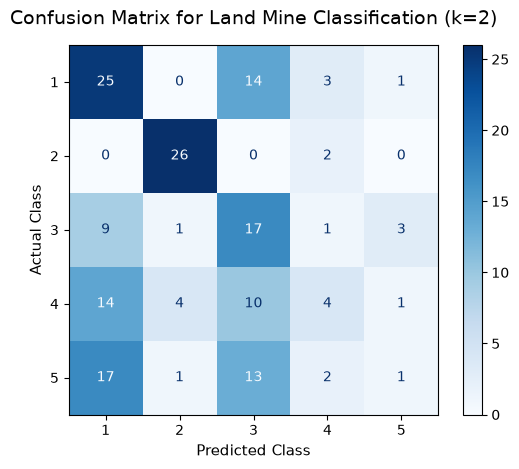

In [14]:
# --- CELL 4: Evaluate Best Model ---
# (CHANGED: Switched n_neighbors=5 to n_neighbors=eval_k_star so it dynamically uses the true optimal k we just found)
classification_model = KNeighborsClassifier(n_neighbors=eval_k_star).fit(
    eval_X_train_scaled, eval_y_train
)

y_pred = classification_model.predict(eval_X_valid_scaled)

classes = [1, 2, 3, 4, 5]

cm = confusion_matrix(eval_y_valid, y_pred, labels=classes)
print(cm)

# (CHANGED: Added a dynamic calculation of overall accuracy to print above the matrix)
overall_acc = accuracy_score(eval_y_valid, y_pred)
print(f"Overall Accuracy: {overall_acc * 100:.2f}%")

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)
disp.plot(cmap=plt.cm.Blues)
plt.title(f"Confusion Matrix for Land Mine Classification (k={eval_k_star})", fontsize=14, pad=15) 
# (CHANGED: Added the dynamic k value to the title for clarity)
plt.xlabel("Predicted Class", fontsize=11)
plt.ylabel("Actual Class", fontsize=11)
plt.show()

Accuracy Analysis:The overall accuracy of the optimal $k=2$ model is 43.20% (73 correct predictions out of 169 validation samples). Performance varies drastically by class:More accurate: The model performs best on Class 1 and Class 2 mines, rarely confusing them for other types.Less accurate: It is terribly inaccurate for Classes 4 and 5. For example, it only correctly identified Class 5 one single time, heavily misclassifying it as Class 1 or Class 3 instead.

5. Given the life-or-death context of humanitarian land mine removal, an overall accuracy of 43.20% is far too low for this model to be used for real-world decision-making. While the model performs relatively well at identifying Class 1 and Class 2 mines, it performs poorly on Class 5 mines. Misclassifying a mine could lead a field worker to use an inappropriate removal procedure, creating serious safety risks. Therefore, I would strongly advise against using this predictive model to make final decisions in practice. It could potentially be used as a preliminary exploratory tool, but better feature data and more robust modeling methods would be needed before relying on its predictions in the field.

### *Reflection on AI assistance
In your own words without generative AI.

[In 150–300 words, describe the main improvements, AI mistakes or limitations, how the final solution was verified, and any remaining concerns.]

The biggest improvement to my Phase 1 submission was fixing a major mistake in Question 2. I originally used Sum of Squared Errors (SSE) to figure out the best k for my model. The AI helped me realize that since land mine types are just categories (1 through 5) and not actual measurements, using SSE is mathematically wrong. It helped me switch to using accuracy instead, which changed my best k from 5 to 2. It also helped clean up my short answers, like clarifying that we tune parameters on a validation set so we don't accidentally cheat by using the test set early. I verified the changes by actually running the updated Python code in my Jupyter Notebook. I made sure the new 43.2% accuracy score and the new confusion matrix generated correctly and matched what the AI was saying in the text. My main concern now is just how bad the final model is. Even with the corrected math, the accuracy is only 43.2%. The confusion matrix shows it completely fails to identify Class 4 and 5 mines. Because of this, I'm worried that either k-NN is just a bad model for this dataset, or the three features we have aren't enough to safely find land mines in real life. I think a limitation is how AI didn't show me how to fix this accuracy.